In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import itertools
import time
from joblib import Parallel, delayed

In [2]:
import yfinance as yf
import pandas as pd

def fetch_turtle_universe():
    print("🌍 Initialisation du téléchargement de l'univers Turtle...")
    
    # 1. Sélection des Tickers (Le panier macro-économique)
    turtle_assets = {
        'Commodities': ['GC=F', 'CL=F', 'SI=F', 'HG=F', 'ZC=F'], # Or, Pétrole Brut, Argent, Cuivre, Maïs
        'Forex': ['EURUSD=X', 'USDJPY=X', 'GBPUSD=X'],           # Euro, Yen, Livre Sterling                                # Bons du Trésor US 20+ ans et 7-10 ans
        #'Crypto': ['BTC-USD', 'ETH-USD'], 
        'Indice': ['QQQ']                        # Bitcoin, Ethereum
    }
    
    # Aplatissement du dictionnaire en une seule liste de tickers
    tickers = [ticker for category in turtle_assets.values() for ticker in category]
    
    # 2. Téléchargement depuis Yahoo Finance (Historique long)
    print(f"📥 Téléchargement de {len(tickers)} actifs depuis 1900...")
    raw_data = yf.download(tickers, start="1900-01-01", interval='1d', progress=True)
    
    # 3. Transformation des données (Wide to Long Format)
    print("⚙️ Restructuration du DataFrame pour l'algorithme...")
    
    # yfinance renvoie un MultiIndex. On "empile" (stack) le niveau des Tickers pour en faire une colonne
    # Le level=1 correspond généralement aux Tickers dans les récentes versions de yfinance
    df = raw_data.stack(level=1, future_stack=True).reset_index()
    
    # 4. Renommage strict pour correspondre à ton algorithme
    # (Attention à la casse des lettres, Pandas ne pardonne pas)
    df = df.rename(columns={
        'Date': 'date',
        'Ticker': 'symbol', # Le nom généré par stack()
        'High': 'high',
        'Low': 'low',
        'Close': 'close',
        'Open': 'open',
        'Volume': 'volume'
    })
    
    # 5. Nettoyage et tri final
    # On s'assure que la date est au bon format
    df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None) 
    
    # Tri par actif puis par date chronologique
    df = df.sort_values(by=['symbol', 'date']).reset_index(drop=True)
    
    # Suppression des jours sans cotation (ex: jours fériés)
    df = df.dropna(subset=['close', 'high', 'low'])
    
    print(f"✅ Terminé ! DataFrame généré avec {len(df)} lignes.")
    return df

# ==========================================
# 🚀 EXÉCUTION
# ==========================================
df = fetch_turtle_universe()

# Vérification visuelle
print("\nAperçu des données prêtes pour le backtest :")
display(df.head())
print("\nListe des actifs disponibles dans df :", df['symbol'].unique())

🌍 Initialisation du téléchargement de l'univers Turtle...
📥 Téléchargement de 9 actifs depuis 1900...


[*********************100%***********************]  9 of 9 completed

⚙️ Restructuration du DataFrame pour l'algorithme...
✅ Terminé ! DataFrame généré avec 58095 lignes.

Aperçu des données prêtes pour le backtest :


Price,date,symbol,close,high,low,open,volume
981,2000-08-23,CL=F,32.049999,32.799999,31.950001,31.950001,79385.0
982,2000-08-24,CL=F,31.629999,32.240002,31.400000,31.900000,72978.0
983,2000-08-25,CL=F,32.049999,32.099998,31.320000,31.700001,44601.0
984,2000-08-28,CL=F,32.869999,32.919998,31.860001,32.040001,46770.0
985,2000-08-29,CL=F,32.720001,33.029999,32.560001,32.820000,49131.0



Liste des actifs disponibles dans df : ['CL=F' 'EURUSD=X' 'GBPUSD=X' 'GC=F' 'HG=F' 'QQQ' 'SI=F' 'USDJPY=X' 'ZC=F']


In [3]:
# ==========================================
# 1. GÉNÉRATION DES SIGNAUX (MOMENTUM + REBALANCEMENT)
# ==========================================
def generate_momentum_signals(
    df,
    ma_short=50,
    ma_long=200,
    mom_window=90,      
    top_n=1,
    rebalance_freq='M'  # ⚠️ NOUVEAU : 'W' (Semaine), 'M' (Mois), 'Y' (Année)
):
    required_cols = ['symbol', 'date', 'close']
    data = df[required_cols].copy()
    data = data.sort_values(['symbol', 'date'])

    # 1. Indicateurs
    data['MA_Short'] = data.groupby('symbol')['close'].transform(lambda x: x.rolling(ma_short).mean())
    data['MA_Long'] = data.groupby('symbol')['close'].transform(lambda x: x.rolling(ma_long).mean())
    data['Mom'] = data.groupby('symbol')['close'].transform(lambda x: (x / x.shift(mom_window)) - 1)

    # 2. Conditions Logiques (Achat uniquement pour filtrer le risque crypto)
    c1_long = (data['MA_Short'] > data['MA_Long']) & (data['close'] > data['MA_Long'])
    c2_long = (data['MA_Short'] < data['MA_Long']) & (data['close'] > data['MA_Short'])
    data['Eligible_Long'] = c1_long | c2_long
    data['Eligible_Short'] = False 

    data['Mom_Long'] = np.where(data['Eligible_Long'], data['Mom'], np.nan)

    # 3. 🛡️ GESTION DU REBALANCEMENT DYNAMIQUE
    # to_period convertit la date en période ('W' = semaine, 'M' = mois, 'Y' = année)
    data['Period'] = data['date'].dt.to_period(rebalance_freq)
    
    # On trouve la dernière date de cotation pour chaque période et chaque actif
    rebalance_dates = data.groupby(['symbol', 'Period'])['date'].transform('max')
    data['Is_Rebalance_Day'] = data['date'] == rebalance_dates

    # 4. Classement (Uniquement le jour du rebalancement)
    data['Rank_Long'] = np.nan
    mask_rebalance = data['Is_Rebalance_Day'] & data['Eligible_Long']
    data.loc[mask_rebalance, 'Rank_Long'] = data[mask_rebalance].groupby('date')['Mom_Long'].rank(ascending=False, method='first')

    # 5. Application du Signal
    data['Signal'] = np.nan
    data.loc[data['Is_Rebalance_Day'] & (data['Rank_Long'] <= top_n), 'Signal'] = 1
    data.loc[data['Is_Rebalance_Day'] & (data['Signal'].isna()), 'Signal'] = 0
    
    # 6. Maintien de la position jusqu'au prochain rebalancement
    data['Signal'] = data.groupby('symbol')['Signal'].ffill().fillna(0)

    # Poids
    data['Target_Weight'] = data['Signal'] * (1.0 / top_n)
    data['NextReturn'] = data.groupby('symbol')['close'].shift(-1) / data['close'] - 1
    
    return data.dropna(subset=['NextReturn', 'MA_Long', 'Mom'])

In [4]:
def run_vectorized_backtest(data, transaction_cost=0.0005): # 0.05% de frais
    data['Weight_Change'] = data.groupby('symbol')['Target_Weight'].diff().fillna(data['Target_Weight'])
    data['Cost'] = data['Weight_Change'].abs() * transaction_cost
    data['Strat_Return'] = data['Target_Weight'] * data['NextReturn']
    data['is_trade'] = (data['Weight_Change'].abs() > 0.001).astype(int)
    
    port_returns = data.groupby('date')[['Strat_Return', 'Cost', 'is_trade']].sum()
    port_returns['Net_Return'] = port_returns['Strat_Return'] - port_returns['Cost']
    port_returns['Capital'] = (1 + port_returns['Net_Return']).cumprod()
    return port_returns

In [5]:
def run_single_backtest_mom(params, df_source, start_date, end_date):
    # 🛠️ 5 Paramètres désormais
    ma_s, ma_l, mom_win, n_top, reb_freq = params

    default_output = {
        "MA_Short": ma_s, "MA_Long": ma_l, "Mom_Window": mom_win, 
        "Top_N": n_top, "Rebalance": reb_freq,
        "Total Return": np.nan, "CAGR": np.nan, "Calmar Ratio": np.nan,
        "Max Drawdown": np.nan, "Sharpe Ratio": np.nan, "Error": None
    }

    try:
        df_source = df_source.copy()
        df_source['date'] = pd.to_datetime(df_source['date'])
        
        full_signals = generate_momentum_signals(
            df_source, ma_short=ma_s, ma_long=ma_l, 
            mom_window=mom_win, top_n=n_top, rebalance_freq=reb_freq
        )

        mask = (full_signals['date'] >= pd.to_datetime(start_date)) & (full_signals['date'] <= pd.to_datetime(end_date))
        backtest_data = full_signals.loc[mask].copy()

        if backtest_data.empty:
            default_output["Error"] = "No data"
            return default_output

        res_df = run_vectorized_backtest(backtest_data, transaction_cost=0.0005)

        final_cap = res_df['Capital'].iloc[-1]
        n_days = (res_df.index[-1] - res_df.index[0]).days
        n_years = n_days / 365.25 if n_days >= 1 else 1.0
        
        cagr = (final_cap ** (1 / n_years)) - 1 if final_cap > 0 else -1.0
        rolling_max = res_df['Capital'].cummax()
        max_dd = ((res_df['Capital'] - rolling_max) / rolling_max).min() if rolling_max.iloc[-1] > 0 else -1.0
        mean_ret = res_df['Net_Return'].mean()
        std_ret = res_df['Net_Return'].std()
        sharpe = (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else 0 
        calmar = abs(cagr / max_dd) if max_dd != 0 else 0 

        output = default_output.copy()
        output.update({
            "Total Return": final_cap - 1, "CAGR": cagr,
            "Calmar Ratio": calmar, "Max Drawdown": max_dd, "Sharpe Ratio": sharpe
        })
        return output
    except Exception as e:
        default_output["Error"] = repr(e) 
        return default_output

In [6]:
def grid_search_execution_mom(df, param_grid, start_date, end_date):
    keys, values = zip(*param_grid.items())
    combinations = [v for v in itertools.product(*values) if v[0] < v[1]]

    print(f"🚀 Lancement de la Grid Search Momentum sur {len(combinations)} combinaisons...")
    start_time = time.time()

    results_list = Parallel(n_jobs=-1)(
        delayed(run_single_backtest_mom)(params, df, start_date, end_date) for params in combinations
    )

    end_time = time.time()
    print(f"✅ Terminé en {end_time - start_time:.2f} secondes.")

    results_df = pd.DataFrame(results_list)
    if results_df.empty or 'Error' not in results_df.columns:
        return results_df
    
    best_strats = results_df[results_df['Error'].isna()].sort_values(by='CAGR', ascending=False)
    return best_strats

In [7]:
def analyze_best_strategy_mom(best_df, df_source, start_date, end_date):
    if best_df.empty:
        print("❌ Aucune stratégie valide trouvée.")
        return None, None
        
    best_params = best_df.sort_values(by='CAGR', ascending=False).iloc[0]
    
    ma_s = int(best_params['MA_Short'])
    ma_l = int(best_params['MA_Long'])
    mom_win = int(best_params['Mom_Window'])
    n_top = int(best_params['Top_N'])
    reb_freq = best_params['Rebalance']
    
    print("\n🏆 --- RECALCUL DE LA MEILLEURE STRATÉGIE MOMENTUM ---")
    print(f"MA Courte: {ma_s}j | MA Longue: {ma_l}j | Momentum: {mom_win}j | Rebalancement: {reb_freq}")
    
    full_signals = generate_momentum_signals(
        df_source, ma_short=ma_s, ma_long=ma_l, 
        mom_window=mom_win, top_n=n_top, rebalance_freq=reb_freq
    )
    
    mask = (full_signals['date'] >= pd.to_datetime(start_date)) & (full_signals['date'] <= pd.to_datetime(end_date))
    backtest_data = full_signals.loc[mask].copy()
    res_df = run_vectorized_backtest(backtest_data, transaction_cost=0.0005)
    
    try:
        gspc_data = yf.download('^GSPC', start=start_date, end=end_date, interval='1d', progress=False)
        gspc_close = gspc_data['Close']['^GSPC'] if isinstance(gspc_data.columns, pd.MultiIndex) else gspc_data['Close']
        gspc_close.index = pd.to_datetime(gspc_close.index).tz_localize(None)
        
        aligned_gspc = pd.DataFrame(index=pd.to_datetime(res_df.index).tz_localize(None))
        aligned_gspc['GSPC_Price'] = gspc_close.reindex(aligned_gspc.index, method='ffill').bfill()
        res_df['GSPC_Capital'] = aligned_gspc['GSPC_Price'] / aligned_gspc['GSPC_Price'].iloc[0]
    except:
        res_df['GSPC_Capital'] = 1.0 

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})
    
    ax1.plot(res_df.index, res_df['Capital'], color='crimson', linewidth=2.5, 
             label=f"Momentum Strategy (CAGR: {best_params['CAGR']*100:.1f}%, MaxDD: {best_params['Max Drawdown']*100:.1f}%)")
    ax1.plot(res_df.index, res_df['GSPC_Capital'], color='dimgray', linewidth=1.5, linestyle='--', label="S&P 500 (^GSPC)")
    ax1.set_yscale('log')
    ax1.set_title(f"Évolution du Capital - Stratégie Momentum (Rebalancement: {reb_freq})", fontsize=14, fontweight='bold')
    ax1.grid(True, which="both", ls="--", alpha=0.4)
    ax1.legend(loc='upper left', fontsize=12)
    
    ax2.bar(res_df.index, res_df['is_trade'], color='purple', width=3, alpha=0.5, label='Rotations de portefeuille')
    ax2.set_title("Activité de Trading (Changement de champion)", fontsize=12)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return res_df, backtest_data

🚀 Lancement de la Grid Search Momentum sur 480 combinaisons...
✅ Terminé en 3.23 secondes.


,MA_Short,MA_Long,Mom_Window,Top_N,Rebalance,Total Return,CAGR,Calmar Ratio,Max Drawdown,Sharpe Ratio,Error
453,50,200,250,2,W,14.062661,0.136466,0.332121,-0.410891,0.668784,None
213,20,200,250,2,W,12.724029,0.131488,0.298453,-0.440565,0.640607,None
157,20,200,90,3,M,11.072497,0.124666,0.315002,-0.395763,0.699988,None
456,50,200,250,3,W,10.457052,0.121894,0.366721,-0.332389,0.691367,None
191,20,200,120,4,Y,10.058389,0.120021,0.228679,-0.524847,0.720949,None



🏆 --- RECALCUL DE LA MEILLEURE STRATÉGIE MOMENTUM ---
MA Courte: 50j | MA Longue: 200j | Momentum: 250j | Rebalancement: W


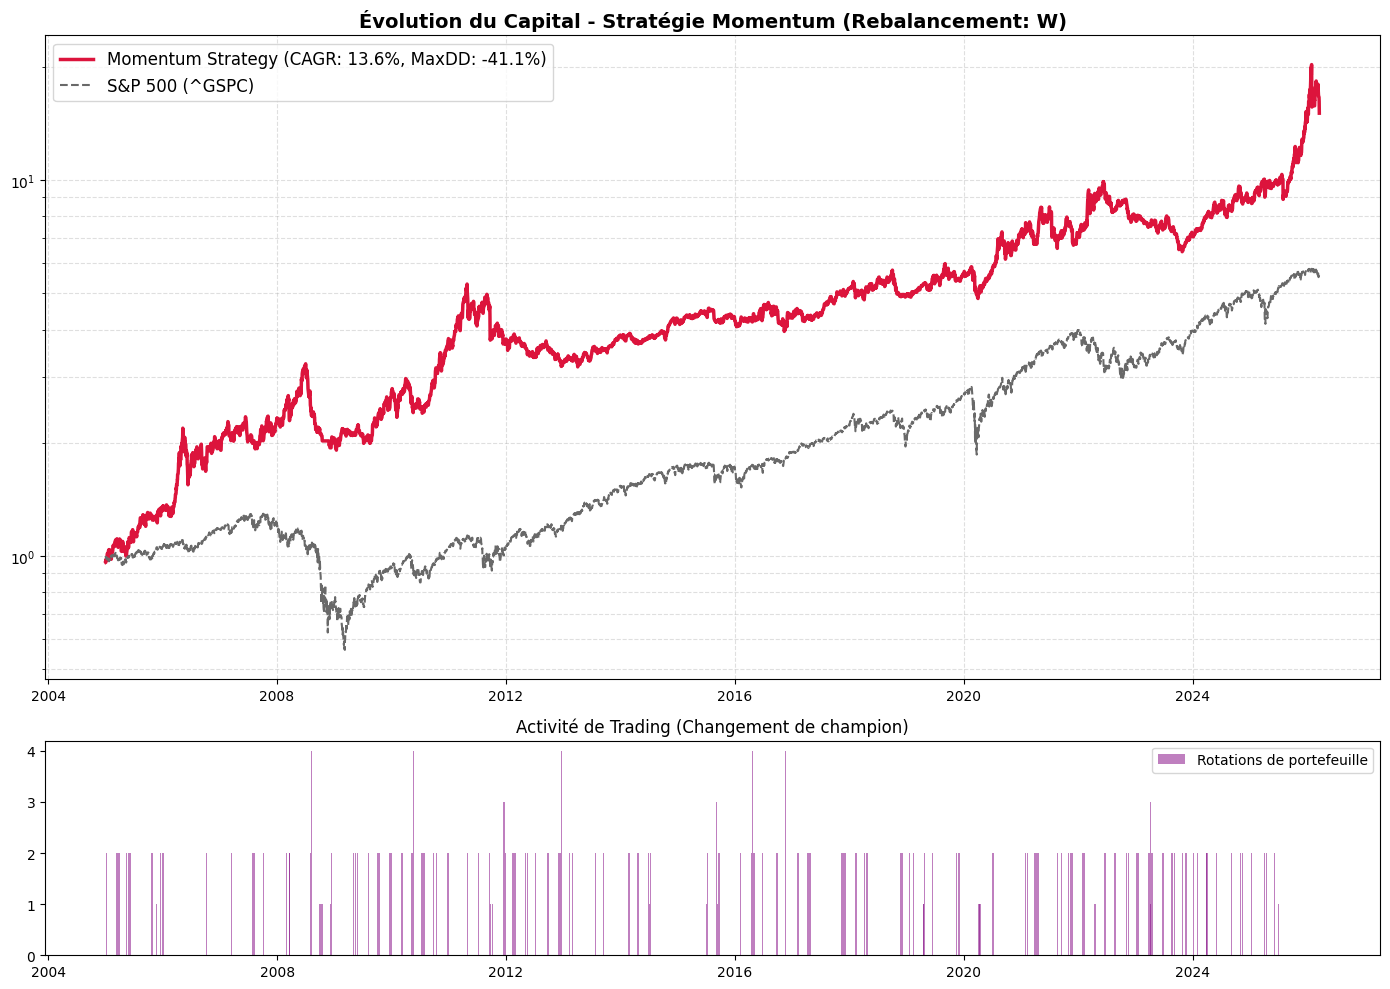

In [13]:
param_grid_mom = {
    'ma_short': [20, 50],               
    'ma_long': [100, 200],              
    'mom_window': [60, 90, 120, 250],     
    'top_n': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],                    
    'rebalance_freq': ['W', 'M', 'Y']     # ⚠️ La magie s'opère ici !
}

# 🚀 Lancement !
best_mom_strats = grid_search_execution_mom(df, param_grid_mom, start_date='2005-01-01', end_date='2026-03-18')

display(best_mom_strats.head(5))

# Analyse finale
stats, trades = analyze_best_strategy_mom(best_mom_strats, df, start_date='2005-01-01', end_date='2026-03-18')

In [9]:
all_trades_history[all_trades_history['Signal']!=0].sort_values(by=['date'], ascending=False)

NameError: name 'all_trades_history' is not defined